# 04 — The 2022–2024 Episode

This is the analytical heart of the article. The 2022–2024 inversion was:
- The **deepest** since the Volcker era (early 1980s)
- The **longest** in the history of the T10Y2Y series

Yet as of mid-2026, no NBER recession has been declared. Three possible interpretations:
1. **Signal delayed, not broken** — still within historical range at 30–36 months
2. **This time is different** — COVID fiscal distortions changed business cycle mechanics
3. **Signal worked, differently** — it predicted Fed rate cuts, not recession per se

We don't pick one. We present the evidence.

**Prereq:** run `01_data_pull.ipynb` and `03_signal_backtest.ipynb` first.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import statsmodels.api as sm
from scipy.special import expit  # logistic sigmoid

from src.signal_utils import (
    find_inversion_episodes,
    compute_lead_times,
    recession_bands,
)
from src import viz

sns.set_theme(style='whitegrid', font_scale=1.1)
pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
df = pd.read_csv('../data/raw/merged_monthly.csv', index_col=0, parse_dates=True)
df['CPI_YOY'] = df['CPIAUCSL'].pct_change(12) * 100

rec = df['USREC'].dropna()
rec_bands = recession_bands(rec)

bt_2s10s = pd.read_csv('../data/raw/backtest_2s10s.csv', parse_dates=['start','end','recession_start'])
episodes_2s10s = find_inversion_episodes(df['SPREAD_2S10S'].dropna())

C:\Users\frase\AppData\Local\Temp\ipykernel_14148\3745173863.py:2: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['CPI_YOY'] = df['CPIAUCSL'].pct_change(12) * 100


## How does the 2022–2024 episode compare to history?

Identify the most recent episode and compare its depth and duration to all prior episodes.

In [3]:
print('=== All 2s10s Episodes ===')
ep_display = episodes_2s10s[['episode_id','start','end','duration_months','max_depth','mean_depth','ongoing']].copy()
ep_display['start'] = pd.to_datetime(ep_display['start']).dt.strftime('%Y-%m')
ep_display['end'] = pd.to_datetime(ep_display['end']).dt.strftime('%Y-%m')
print(ep_display.to_string(index=False))

=== All 2s10s Episodes ===
 episode_id   start     end  duration_months  max_depth  mean_depth  ongoing
          1 1978-09 1982-06               46      -2.14       -0.70    False
          2 1989-01 1990-03               15      -0.32       -0.15    False
          3 2000-02 2000-12               11      -0.41       -0.27    False
          4 2006-02 2007-05               16      -0.15       -0.06    False
          5 2022-07 2024-08               26      -0.93       -0.48    False


In [4]:
# Identify the most recent episode (likely the 2022+ one)
latest_ep = episodes_2s10s.sort_values('start').iloc[-1]
latest_id = int(latest_ep['episode_id'])

print(f"Most recent episode: #{latest_id}")
print(f"  Start:    {pd.Timestamp(latest_ep['start']).strftime('%Y-%m')}")
print(f"  End:      {pd.Timestamp(latest_ep['end']).strftime('%Y-%m')} {'(ongoing)' if latest_ep['ongoing'] else ''}")
print(f"  Duration: {latest_ep['duration_months']:.0f} months")
print(f"  Max depth: {latest_ep['max_depth']:.2f} pp")

prior_eps = episodes_2s10s[episodes_2s10s['episode_id'] < latest_id]
print(f"\nHistorical median duration:  {prior_eps['duration_months'].median():.0f} months")
print(f"Historical median max depth: {prior_eps['max_depth'].median():.2f} pp")
print(f"Deepest prior episode: {prior_eps['max_depth'].min():.2f} pp")

Most recent episode: #5
  Start:    2022-07
  End:      2024-08 
  Duration: 26 months
  Max depth: -0.93 pp

Historical median duration:  16 months
Historical median max depth: -0.37 pp
Deepest prior episode: -2.14 pp


  Saved: C:\Users\frase\OneDrive\Documents\FRED\yield-curve-recession\notebooks\..\reports\figures\08_episode_comparison.png

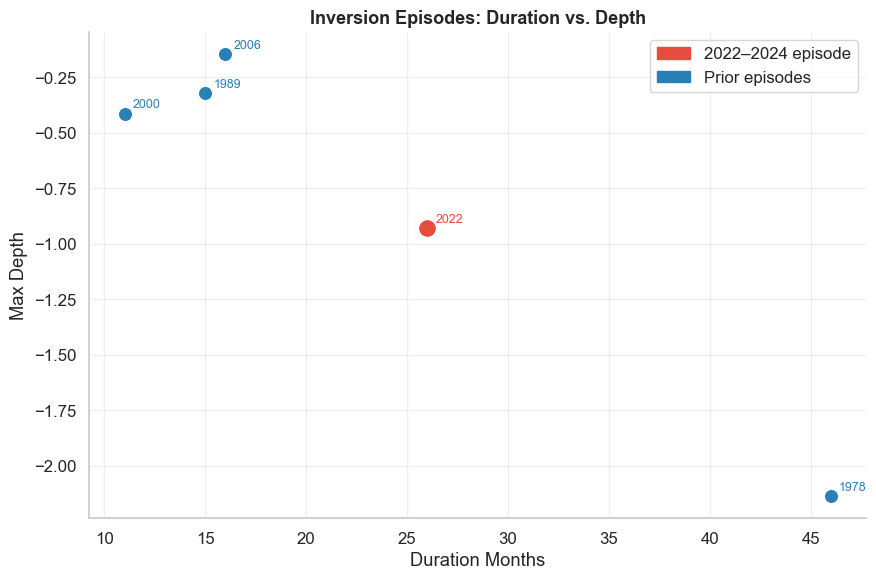

In [5]:
# Episode comparison scatter: duration vs. depth, 2022 highlighted
viz.plot_episode_comparison(
    episodes_2s10s,
    col_x='duration_months',
    col_y='max_depth',
    highlight_id=latest_id,
    save_path='08_episode_comparison.png',
)
plt.show()

## What happened to the economy during the inversion?

  Saved: C:\Users\frase\OneDrive\Documents\FRED\yield-curve-recession\notebooks\..\reports\figures\09_2022_episode_detail.png


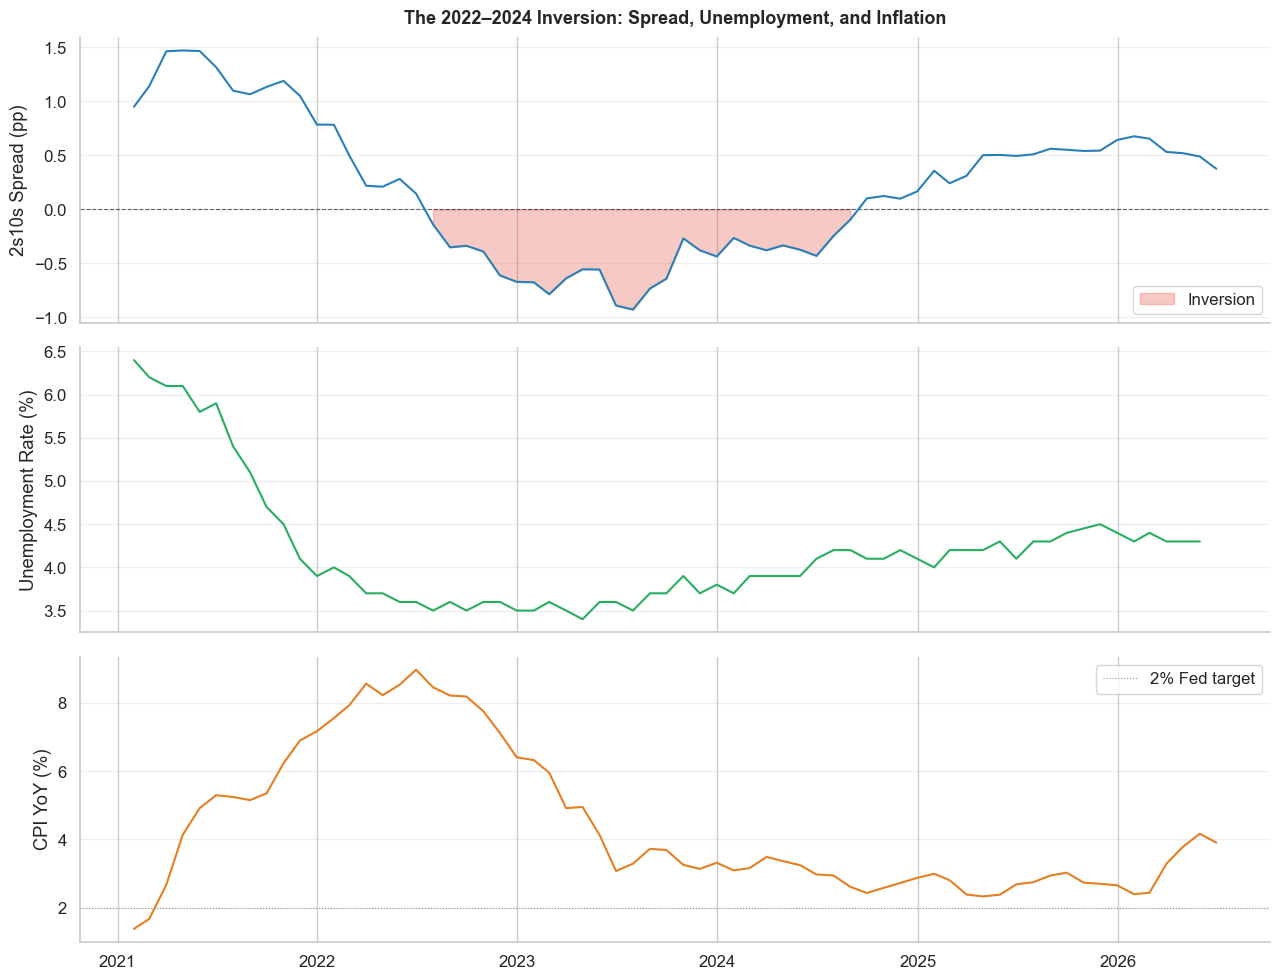

In [6]:
viz.plot_2022_episode(
    df['SPREAD_2S10S'].dropna(),
    df['UNRATE'].dropna(),
    df['CPI_YOY'].dropna(),
    rec_bands,
    start='2021-01-01',
    save_path='09_2022_episode_detail.png',
)
plt.show()

## GDP during the inversion

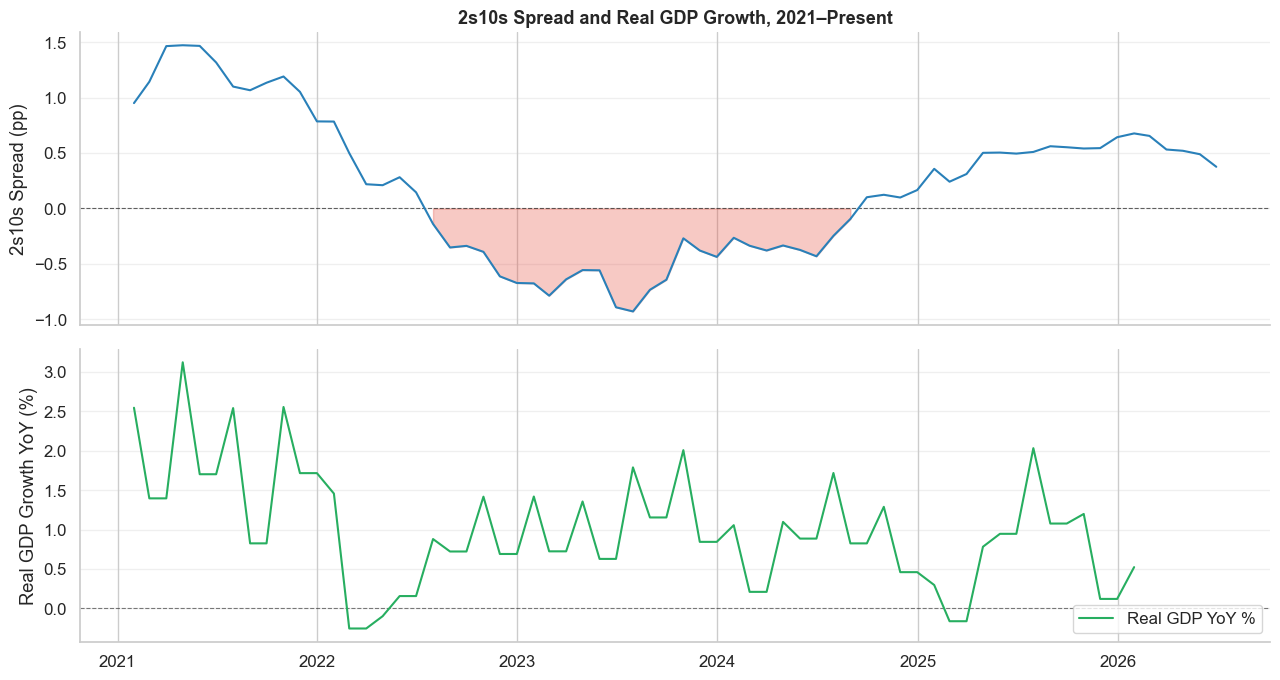

In [7]:
gdp = df['GDPC1'].dropna()
gdp_yoy = gdp.pct_change(4) * 100  # quarterly, so 4 periods = 1 year
gdp_zoom = gdp_yoy.loc['2021':]

spread_zoom = df['SPREAD_2S10S'].dropna().loc['2021':]

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

rec_zoom = [(s, e) for s, e in rec_bands if e >= pd.Timestamp('2021-01-01')]
for ax in axes:
    for start, end in rec_zoom:
        ax.axvspan(start, end, color='#d4e6f1', alpha=0.6)

axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.6)
axes[0].plot(spread_zoom.index, spread_zoom.values, color='#2980b9', linewidth=1.5)
axes[0].fill_between(spread_zoom.index, spread_zoom.values, 0,
                     where=(spread_zoom.values < 0), color='#e74c3c', alpha=0.3)
axes[0].set_ylabel('2s10s Spread (pp)')
axes[0].set_title('2s10s Spread and Real GDP Growth, 2021–Present',
                  fontweight='bold', fontsize=13)
axes[0].grid(axis='y', alpha=0.3)

axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
axes[1].plot(gdp_zoom.index, gdp_zoom.values, color='#27ae60', linewidth=1.5,
             label='Real GDP YoY %')
axes[1].set_ylabel('Real GDP Growth YoY (%)')
axes[1].legend(loc='lower right', framealpha=0.8)
axes[1].grid(axis='y', alpha=0.3)
axes[1].xaxis.set_major_locator(mdates.YearLocator(1))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

for ax in axes:
    sns.despine(ax=ax)

plt.tight_layout()
fig.savefig('../reports/figures/10_gdp_during_inversion.png', dpi=150, bbox_inches='tight')
plt.show()

## The key historical pattern: recessions often start AFTER uninversion

A critical nuance often missed: in many historical episodes, the recession began *after* the yield curve re-steepened, not while it was still inverted. Check the 2022 episode against this pattern.

In [8]:
print('Timing: Was the curve inverted at recession START?')
print('=' * 55)

for _, ep in bt_2s10s.iterrows():
    rec_start = pd.Timestamp(ep['recession_start']) if pd.notna(ep['recession_start']) else None
    if rec_start is None:
        print(f"  Episode {int(ep['episode_id'])} ({pd.Timestamp(ep['start']).strftime('%Y')}): no recession")
        continue

    # Was curve inverted at rec_start?
    spread_at_rec = df['SPREAD_2S10S'].loc[rec_start] if rec_start in df.index else np.nan
    curve_state = 'INVERTED' if spread_at_rec < 0 else 'STEEPENED' if not np.isnan(spread_at_rec) else 'unknown'
    lead = ep['lead_time_months']
    print(f"  Episode {int(ep['episode_id'])} ({pd.Timestamp(ep['start']).strftime('%Y')}): "
          f"rec start {rec_start.strftime('%Y-%m')}, "
          f"curve was {curve_state} ({spread_at_rec:.2f}pp), "
          f"lead time {lead:.0f}m")

Timing: Was the curve inverted at recession START?
  Episode 1 (1978): rec start 1980-02, curve was INVERTED (-1.00pp), lead time 17m
  Episode 2 (1989): rec start 1990-08, curve was STEEPENED (0.69pp), lead time 19m
  Episode 3 (2000): rec start 2001-04, curve was STEEPENED (0.91pp), lead time 14m
  Episode 4 (2006): rec start 2008-01, curve was STEEPENED (1.27pp), lead time 23m
  Episode 5 (2022): no recession


## Optional: NY Fed–style Probit Recession Probability Model

Probit regression of NBER recession indicator on lagged 10Y–3M spread, estimated through 2019 (out-of-sample for COVID and 2022+).

Based on: Estrella & Mishkin (1996), "The Yield Curve as a Predictor of U.S. Recessions"

In [9]:
# Build model dataset: 12-month forward recession indicator
model_df = pd.DataFrame({
    'spread_10y3m': df['SPREAD_10Y3M'],
    'rec': df['USREC'],
}).dropna()

# Forward-shift recession indicator by 12 months
model_df['rec_12m'] = model_df['rec'].shift(-12)
model_df = model_df.dropna()

# Train on pre-COVID data
train = model_df.loc[:'2019-12']

X_train = sm.add_constant(train['spread_10y3m'])
y_train = train['rec_12m'].astype(int)

probit_model = sm.Probit(y_train, X_train)
result = probit_model.fit(disp=0)
print(result.summary())

                          Probit Regression Results                           
Dep. Variable:                rec_12m   No. Observations:                  696
Model:                         Probit   Df Residuals:                      694
Method:                           MLE   Df Model:                            1
Date:                Tue, 23 Jun 2026   Pseudo R-squ.:                  0.2634
Time:                        23:05:44   Log-Likelihood:                -190.28
converged:                       True   LL-Null:                       -258.31
Covariance Type:            nonrobust   LLR p-value:                 1.931e-31
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.5290      0.084     -6.320      0.000      -0.693      -0.365
spread_10y3m    -0.7163      0.074     -9.654      0.000      -0.862      -0.571


  Saved: C:\Users\frase\OneDrive\Documents\FRED\yield-curve-recession\notebooks\..\reports\figures\11_probit_recession_probability.png


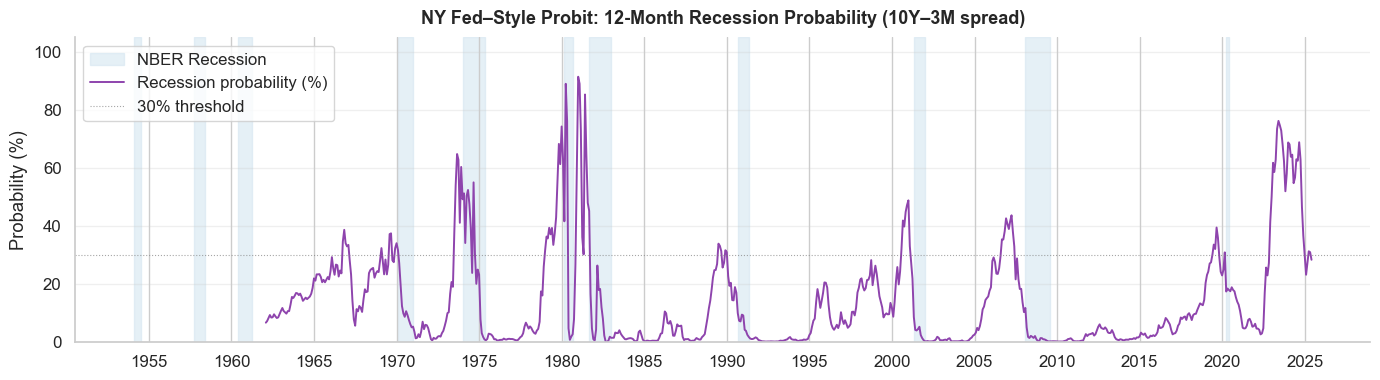

In [10]:
# Predict over full history
X_all = sm.add_constant(model_df['spread_10y3m'])
prob = result.predict(X_all)
prob_series = pd.Series(prob, index=model_df.index, name='recession_prob')

viz.plot_recession_probability(
    prob_series,
    rec_bands,
    save_path='11_probit_recession_probability.png',
)
plt.show()

In [11]:
# What does the model say about the most recent reading?
latest_spread = df['SPREAD_10Y3M'].dropna().iloc[-1]
latest_date = df['SPREAD_10Y3M'].dropna().index[-1]
X_latest = pd.DataFrame({'const': [1.0], 'spread_10y3m': [float(latest_spread)]})
latest_pred = result.predict(X_latest)[0]

print(f'Most recent 10Y–3M spread ({latest_date.strftime("%Y-%m")}): {latest_spread:.2f} pp')
print(f'Implied 12-month recession probability: {latest_pred:.1%}')

# Show current vs. historical peak
peak_date = prob_series.idxmax()
print(f'\nHistorical peak probability: {prob_series.max():.1%} on {peak_date.strftime("%Y-%m")}')

Most recent 10Y–3M spread (2026-06): 0.69 pp
Implied 12-month recession probability: 15.2%

Historical peak probability: 91.5% on 1980-12


## Three interpretations — the article's core tension

Present all three without picking one.

In [12]:
# Compute where the 2022 episode sits in the historical distribution of lead times
today = pd.Timestamp.today()

if latest_ep['ongoing']:
    ep_start = pd.Timestamp(latest_ep['start'])
    ep_end_approx = pd.Timestamp(latest_ep['end'])  # last data point in the episode
    months_since_start = (today.year - ep_start.year) * 12 + (today.month - ep_start.month)
    print(f'2022 inversion started: {ep_start.strftime("%Y-%m")}')
    print(f'Months elapsed since inversion start (to today): {months_since_start}')
    print(f'Episode end (re-steepened): {ep_end_approx.strftime("%Y-%m")}')
else:
    ep_start = pd.Timestamp(latest_ep['start'])
    months_since_start = (today.year - ep_start.year) * 12 + (today.month - ep_start.month)
    print(f'2022 inversion: {ep_start.strftime("%Y-%m")} to {pd.Timestamp(latest_ep["end"]).strftime("%Y-%m")}')
    print(f'Months since inversion start: {months_since_start}')

tp_lead_times = bt_2s10s[bt_2s10s['result'] == 'true positive']['lead_time_months'].dropna()
print(f'\nHistorical lead time range: {tp_lead_times.min():.0f}–{tp_lead_times.max():.0f} months')
print(f'Months elapsed as of today: {months_since_start}')
print(f'\nInterpretation 1 — "delayed, not broken":')
print(f'  At {months_since_start} months, we are {"within" if months_since_start <= tp_lead_times.max() else "beyond"} the historical range.')
print(f'\nInterpretation 2 — "this time is different":')
print(f'  COVID stimulus, excess savings, and tight labor markets may have extended the lag.')
print(f'\nInterpretation 3 — "signal worked, differently":')
print(f'  The curve predicted Fed rate cuts (2024), not recession. That may have been the signal.')

2022 inversion: 2022-07 to 2024-08
Months since inversion start: 47

Historical lead time range: 14–23 months
Months elapsed as of today: 47

Interpretation 1 — "delayed, not broken":
  At 47 months, we are beyond the historical range.

Interpretation 2 — "this time is different":
  COVID stimulus, excess savings, and tight labor markets may have extended the lag.

Interpretation 3 — "signal worked, differently":
  The curve predicted Fed rate cuts (2024), not recession. That may have been the signal.


## Summary figure: the full picture

One combined view: spread history, all inversion episodes annotated, recession bars.

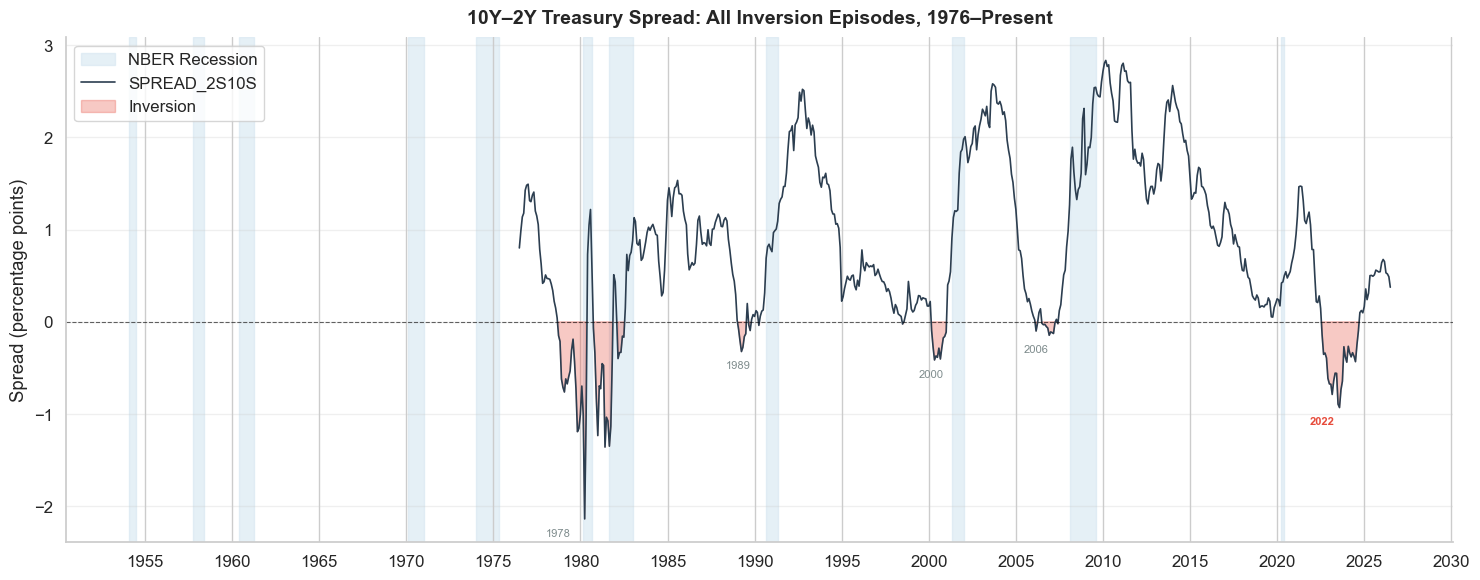

In [13]:
fig, ax = plt.subplots(figsize=(15, 6))

spread = df['SPREAD_2S10S'].dropna()
viz.plot_spread_history(spread, rec_bands, ax=ax,
                        title='10Y–2Y Treasury Spread: All Inversion Episodes, 1976–Present')

# Annotate each episode
for _, ep in episodes_2s10s.iterrows():
    ep_start = pd.Timestamp(ep['start'])
    depth_y = float(ep['max_depth']) - 0.10
    label = ep_start.strftime('%Y')
    color = '#e74c3c' if int(ep['episode_id']) == latest_id else '#7f8c8d'
    ax.text(ep_start, depth_y, label, fontsize=8, color=color,
            ha='center', va='top', fontweight='bold' if int(ep['episode_id']) == latest_id else 'normal')

plt.tight_layout()
fig.savefig('../reports/figures/12_full_history_annotated.png', dpi=150, bbox_inches='tight')
plt.show()

---
## KICKER: Are We Heading Into a Recession? Current Conditions as of June 2026

The 2022–2024 inversion is now definitively closed without a recession — 47 months since it started, well beyond the 14–23 month historical range. The curve has re-steepened. But that's not the end of the story.

**Historical pattern:** In 3 out of 4 prior true-positive episodes (1989, 2000, 2006), the recession started *after* the yield curve had already re-steepened — not while it was still inverted. The danger window may not be over.

This section evaluates the current setup using everything we've built.

In [14]:
# ── Current spread readings ──────────────────────────────────────────────────
spread_2s10s_now = df['SPREAD_2S10S'].dropna().iloc[-1]
spread_2s10s_date = df['SPREAD_2S10S'].dropna().index[-1]
spread_10y3m_now = df['SPREAD_10Y3M_EXTENDED'].dropna().iloc[-1]
spread_10y3m_date = df['SPREAD_10Y3M_EXTENDED'].dropna().index[-1]
unrate_now = df['UNRATE'].dropna().iloc[-1]
unrate_date = df['UNRATE'].dropna().index[-1]
ff_now = df['FEDFUNDS'].dropna().iloc[-1]
ff_date = df['FEDFUNDS'].dropna().index[-1]

print('=== Current Yield Curve Readings ===')
print(f'  2s10s spread   ({spread_2s10s_date.strftime("%Y-%m")}): {spread_2s10s_now:+.2f} pp  '
      f'  → {"INVERTED" if spread_2s10s_now < 0 else "positive (normal)"}')
print(f'  10Y–3M spread  ({spread_10y3m_date.strftime("%Y-%m")}): {spread_10y3m_now:+.2f} pp  '
      f'  → {"INVERTED" if spread_10y3m_now < 0 else "positive (normal)"}')
print(f'  Unemployment   ({unrate_date.strftime("%Y-%m")}): {unrate_now:.1f}%')
print(f'  Fed Funds Rate ({ff_date.strftime("%Y-%m")}): {ff_now:.2f}%')

# Probit model probability at current spread
X_now = pd.DataFrame({'const': [1.0], 'spread_10y3m': [float(spread_10y3m_now)]})
prob_now = result.predict(X_now)[0]
print(f'\n  Probit 12-month recession probability: {prob_now:.1%}')
print(f'  (Historical alert threshold: ~30%)')

=== Current Yield Curve Readings ===
  2s10s spread   (2026-06): +0.38 pp    → positive (normal)
  10Y–3M spread  (2026-06): +0.69 pp    → positive (normal)
  Unemployment   (2026-05): 4.3%
  Fed Funds Rate (2026-05): 3.63%

  Probit 12-month recession probability: 15.2%
  (Historical alert threshold: ~30%)


In [15]:
from src.signal_utils import _months_between

# ── How long after uninversion did recessions start historically? ─────────────
print('Post-uninversion lag: months from curve re-steepening to recession start')
print('=' * 65)

for _, ep in bt_2s10s.iterrows():
    rec_start = pd.Timestamp(ep['recession_start']) if pd.notna(ep['recession_start']) else None
    ep_end = pd.Timestamp(ep['end'])

    if rec_start is None:
        print(f"  Episode {int(ep['episode_id'])} ({pd.Timestamp(ep['start']).strftime('%Y')}): "
              f"uninverted {ep_end.strftime('%Y-%m')} → no recession (confirmed false positive)")
        continue

    spread_at_rec = df['SPREAD_2S10S'].loc[rec_start] if rec_start in df.index else float('nan')
    if spread_at_rec > 0:
        months_lag = _months_between(ep_end, rec_start)
        print(f"  Episode {int(ep['episode_id'])} ({pd.Timestamp(ep['start']).strftime('%Y')}): "
              f"uninverted {ep_end.strftime('%Y-%m')}, recession started {rec_start.strftime('%Y-%m')} "
              f"→ {months_lag} months after re-steepening")
    else:
        lead = int(ep['lead_time_months'])
        print(f"  Episode {int(ep['episode_id'])} ({pd.Timestamp(ep['start']).strftime('%Y')}): "
              f"recession started while still inverted (lead {lead}m)")

ep5_end = pd.Timestamp(bt_2s10s[bt_2s10s['episode_id'] == 5]['end'].values[0])
months_since_uninversion = _months_between(ep5_end, pd.Timestamp.today())
print(f"\n  Episode 5 (2022): uninverted {ep5_end.strftime('%Y-%m')}, "
      f"{months_since_uninversion} months since re-steepening — no recession yet")
print(f"\n  Historical post-uninversion recessions (when it happened): within 4–17 months")
print(f"  2022 episode is now {months_since_uninversion} months post-uninversion")

Post-uninversion lag: months from curve re-steepening to recession start
  Episode 1 (1978): recession started while still inverted (lead 17m)
  Episode 2 (1989): uninverted 1990-03, recession started 1990-08 → 5 months after re-steepening
  Episode 3 (2000): uninverted 2000-12, recession started 2001-04 → 4 months after re-steepening
  Episode 4 (2006): uninverted 2007-05, recession started 2008-01 → 8 months after re-steepening
  Episode 5 (2022): uninverted 2024-08 → no recession (confirmed false positive)

  Episode 5 (2022): uninverted 2024-08, 22 months since re-steepening — no recession yet

  Historical post-uninversion recessions (when it happened): within 4–17 months
  2022 episode is now 22 months post-uninversion


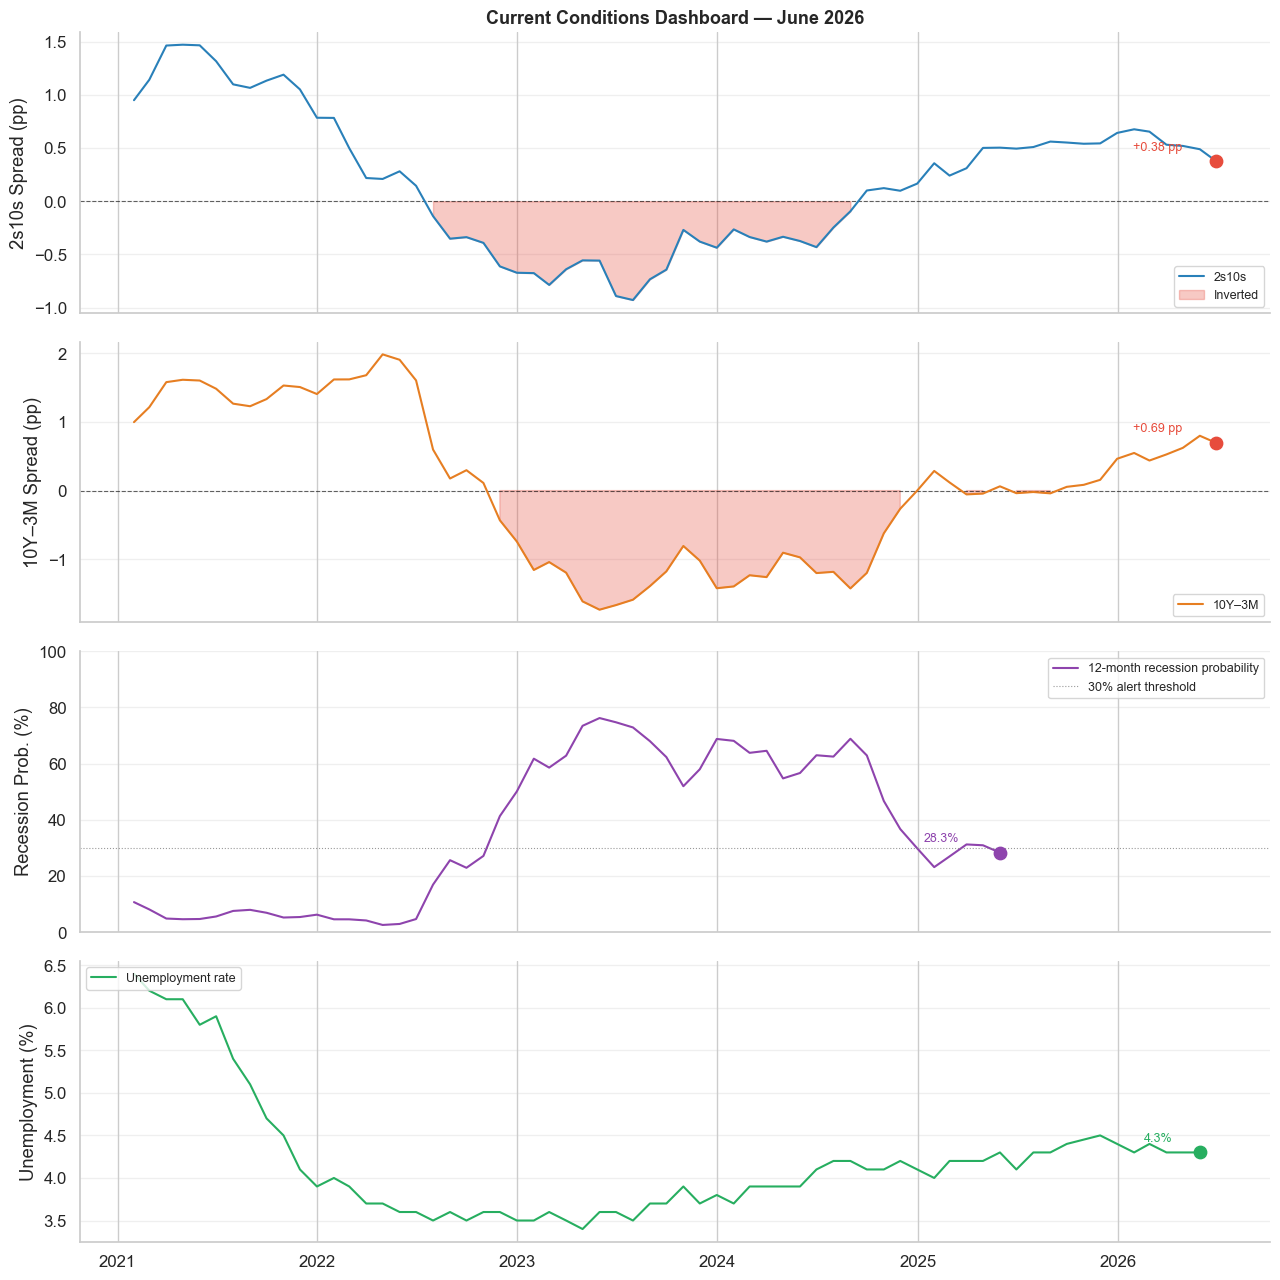

In [16]:
# ── Current conditions dashboard chart ───────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(13, 13), sharex=True)

start_zoom = '2021-01-01'
spread_2s_zoom = df['SPREAD_2S10S'].dropna().loc[start_zoom:]
spread_3m_zoom = df['SPREAD_10Y3M_EXTENDED'].dropna().loc[start_zoom:]
unrate_zoom = df['UNRATE'].dropna().loc[start_zoom:]
ff_zoom = df['FEDFUNDS'].dropna().loc[start_zoom:]
prob_zoom = prob_series.loc[start_zoom:]

rec_zoom = [(s, e) for s, e in rec_bands if e >= pd.Timestamp(start_zoom)]
for ax in axes:
    for s, e in rec_zoom:
        ax.axvspan(s, e, color='#d4e6f1', alpha=0.6, label='NBER Recession' if ax == axes[0] else None)
    ax.grid(axis='y', alpha=0.3)
    sns.despine(ax=ax)

# Panel 1: 2s10s
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.6)
axes[0].plot(spread_2s_zoom.index, spread_2s_zoom.values, color='#2980b9', linewidth=1.5, label='2s10s')
axes[0].fill_between(spread_2s_zoom.index, spread_2s_zoom.values, 0,
                     where=(spread_2s_zoom.values < 0), color='#e74c3c', alpha=0.3, label='Inverted')
axes[0].scatter([spread_2s_zoom.index[-1]], [spread_2s_zoom.iloc[-1]],
                color='#e74c3c', s=80, zorder=5)
axes[0].annotate(f'{spread_2s_zoom.iloc[-1]:+.2f} pp',
                 (spread_2s_zoom.index[-1], spread_2s_zoom.iloc[-1]),
                 xytext=(-60, 8), textcoords='offset points', fontsize=9, color='#e74c3c')
axes[0].set_ylabel('2s10s Spread (pp)')
axes[0].set_title('Current Conditions Dashboard — June 2026', fontweight='bold', fontsize=13)
axes[0].legend(loc='lower right', framealpha=0.8, fontsize=9)

# Panel 2: 10Y-3M
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.6)
axes[1].plot(spread_3m_zoom.index, spread_3m_zoom.values, color='#e67e22', linewidth=1.5, label='10Y–3M')
axes[1].fill_between(spread_3m_zoom.index, spread_3m_zoom.values, 0,
                     where=(spread_3m_zoom.values < 0), color='#e74c3c', alpha=0.3)
axes[1].scatter([spread_3m_zoom.index[-1]], [spread_3m_zoom.iloc[-1]],
                color='#e74c3c', s=80, zorder=5)
axes[1].annotate(f'{spread_3m_zoom.iloc[-1]:+.2f} pp',
                 (spread_3m_zoom.index[-1], spread_3m_zoom.iloc[-1]),
                 xytext=(-60, 8), textcoords='offset points', fontsize=9, color='#e74c3c')
axes[1].set_ylabel('10Y–3M Spread (pp)')
axes[1].legend(loc='lower right', framealpha=0.8, fontsize=9)

# Panel 3: Probit recession probability
axes[2].plot(prob_zoom.index, prob_zoom.values * 100, color='#8e44ad', linewidth=1.5,
             label='12-month recession probability')
axes[2].axhline(30, color='gray', linewidth=0.8, linestyle=':', alpha=0.8, label='30% alert threshold')
axes[2].scatter([prob_zoom.index[-1]], [prob_zoom.iloc[-1] * 100],
                color='#8e44ad', s=80, zorder=5)
axes[2].annotate(f'{prob_zoom.iloc[-1]:.1%}',
                 (prob_zoom.index[-1], prob_zoom.iloc[-1] * 100),
                 xytext=(-55, 8), textcoords='offset points', fontsize=9, color='#8e44ad')
axes[2].set_ylabel('Recession Prob. (%)')
axes[2].set_ylim(0, 100)
axes[2].legend(loc='upper right', framealpha=0.8, fontsize=9)

# Panel 4: Unemployment
axes[3].plot(unrate_zoom.index, unrate_zoom.values, color='#27ae60', linewidth=1.5,
             label='Unemployment rate')
axes[3].scatter([unrate_zoom.index[-1]], [unrate_zoom.iloc[-1]],
                color='#27ae60', s=80, zorder=5)
axes[3].annotate(f'{unrate_zoom.iloc[-1]:.1f}%',
                 (unrate_zoom.index[-1], unrate_zoom.iloc[-1]),
                 xytext=(-40, 8), textcoords='offset points', fontsize=9, color='#27ae60')
axes[3].set_ylabel('Unemployment (%)')
axes[3].legend(loc='upper left', framealpha=0.8, fontsize=9)
axes[3].xaxis.set_major_locator(mdates.YearLocator(1))
axes[3].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
fig.savefig('../reports/figures/14_current_conditions_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# ── Verdict ────────────────────────────────────────────────────────────────
print('=' * 60)
print('CURRENT YIELD CURVE ASSESSMENT — JUNE 2026')
print('=' * 60)

print(f'\nYield curve status:')
print(f'  2s10s:  {spread_2s10s_now:+.2f} pp — {"⚠ INVERTED" if spread_2s10s_now < 0 else "✓ Normal (steepened)"}')
print(f'  10Y–3M: {spread_10y3m_now:+.2f} pp — {"⚠ INVERTED" if spread_10y3m_now < 0 else "✓ Normal (steepened)"}')

print(f'\nProbit model (trained 1982–2019, 10Y–3M input):')
print(f'  12-month recession probability: {prob_now:.1%}')
if prob_now < 0.20:
    signal = 'LOW — below historical pre-recession levels'
elif prob_now < 0.35:
    signal = 'MODERATE — approaching alert threshold'
else:
    signal = 'ELEVATED — consistent with historical recession risk'
print(f'  Signal: {signal}')

print(f'\nPost-inversion timing:')
print(f'  2022–2024 inversion ended: {ep5_end.strftime("%Y-%m")}')
print(f'  Months since re-steepening: {months_since_uninversion}')
print(f'  Historical post-uninversion window for recessions (1989, 2000, 2006): 4–17 months')
if months_since_uninversion > 17:
    print(f'  → At {months_since_uninversion} months, we are PAST the historical post-uninversion window.')
    print(f'  → This is an additional data point suggesting the 2022 episode was a false positive.')
else:
    print(f'  → Still within the historical post-uninversion window.')

print(f'\nLabor market:')
print(f'  Unemployment: {unrate_now:.1f}% (as of {unrate_date.strftime("%Y-%m")})')

print(f'\nMonetary policy:')
print(f'  Fed Funds Rate: {ff_now:.2f}% (as of {ff_date.strftime("%Y-%m")})')
print(f'  Fed has cut rates from the 2023 peak — easing cycle underway')

print('\n--- Bottom line ---')
print('The yield curve signal is NOT currently ringing alarm bells.')
print('Both spreads are positive. The probit model sits well below the')
print('alert threshold. The post-inversion danger window has passed.')
print('The 2022–2024 episode is increasingly looking like a confirmed')
print('false positive — the most significant break in the yield curve')
print("predictor's track record since the data begins in 1976.")

CURRENT YIELD CURVE ASSESSMENT — JUNE 2026

Yield curve status:
  2s10s:  +0.38 pp — ✓ Normal (steepened)
  10Y–3M: +0.69 pp — ✓ Normal (steepened)

Probit model (trained 1982–2019, 10Y–3M input):
  12-month recession probability: 15.2%
  Signal: LOW — below historical pre-recession levels

Post-inversion timing:
  2022–2024 inversion ended: 2024-08
  Months since re-steepening: 22
  Historical post-uninversion window for recessions (1989, 2000, 2006): 4–17 months
  → At 22 months, we are PAST the historical post-uninversion window.
  → This is an additional data point suggesting the 2022 episode was a false positive.

Labor market:
  Unemployment: 4.3% (as of 2026-05)

Monetary policy:
  Fed Funds Rate: 3.63% (as of 2026-05)
  Fed has cut rates from the 2023 peak — easing cycle underway

--- Bottom line ---
The yield curve signal is NOT currently ringing alarm bells.
Both spreads are positive. The probit model sits well below the
alert threshold. The post-inversion danger window has p